# 🧪 Data Science Practical (Advanced)

## Experiment No: 3
## Experiment Title: Advanced Exploratory Data Analysis (EDA)

**Name:** Himanshu Jadhav  
**Roll Number:** SE-33  

---

## Problem Statement

Perform end-to-end EDA on the Titanic dataset — data cleaning, feature engineering, aggregation analysis, correlation heatmap, and outlier detection — using modular, reusable functions.

---

## Implementation

## Step 0: Imports & Plot Config

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings 

warnings.filterwarnings('ignore')

# Plot Theme (Dark)

plt.rcParams.update({
    'figure.facecolor' : '#0b0b18',
    'axes.facecolor'   : '#11112a',
    'axes.edgecolor'   : '#2a2a55',
    'axes.labelcolor'  : '#b0b0d0',
    'xtick.color'      : '#888899',
    'ytick.color'      : '#888899',
    'text.color'       : 'white',
    'grid.color'       : '#1c1c3c',
    'grid.linewidth'   : 0.6,
    'legend.facecolor' : '#11112a',
    'legend.edgecolor' : '#2a2a55',
})
ACCENT = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c','#e67e22']
print('Libraries loaded...')

Libraries loaded...


## Part 1: Load Dataset

In [2]:
df_raw = sns.load_dataset('titanic')

print(f"Shape       : {df_raw.shape}")
print(f"Columns     : {list(df_raw.columns)}")
print(f"Duplicates  : {df_raw.duplicated().sum()}")
print()
df_raw.head()

Shape       : (891, 15)
Columns     : ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']
Duplicates  : 107



,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


## Part 2: Data Cleaning (reusable function)

In [4]:
def missing_report(df):
    """Return sorted DataFrame of missing counts & percentages."""
    miss  = df.isnull().sum()
    pct   = (miss / len(df) * 100).round(2)
    report = pd.DataFrame({'Missing': miss, 'Pct (%)': pct})
    return report[report['Missing'] > 0].sort_values('Pct (%)', ascending=False)

print('Missing Value Report:')
print(missing_report(df_raw).to_string())

Missing Value Report:
             Missing  Pct (%)
deck             688    77.22
age              177    19.87
embarked           2     0.22
embark_town        2     0.22


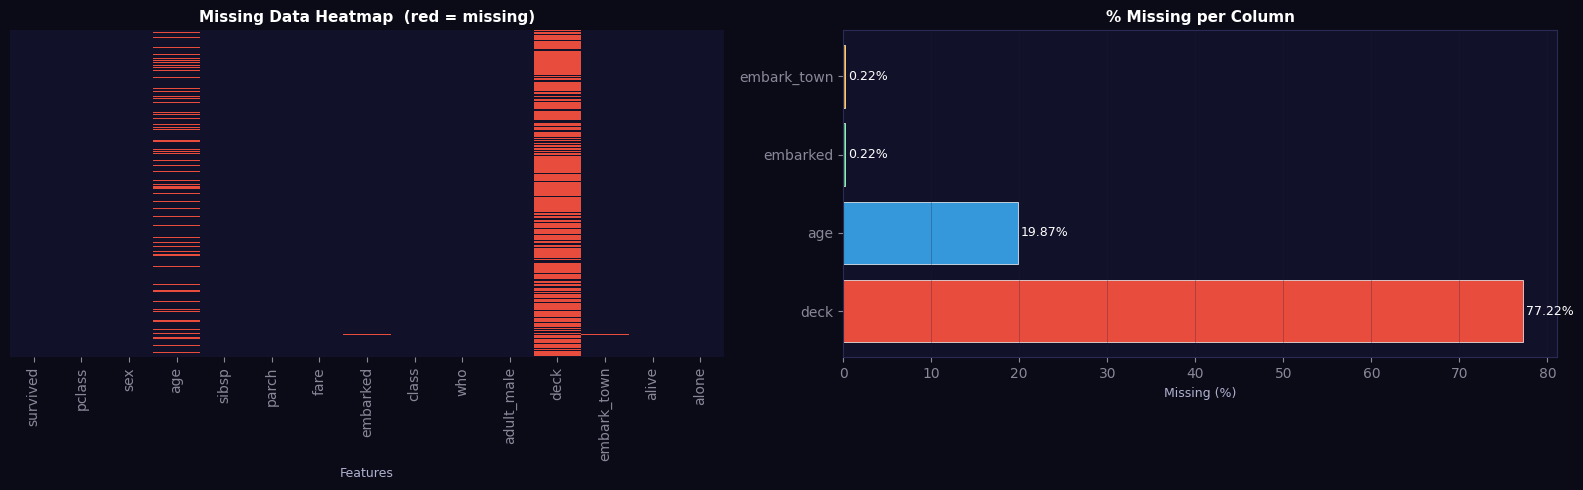

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0b0b18')

# Heatmap: white cell = missing
sns.heatmap(
    df_raw.isnull(),
    ax=axes[0], cbar=False,
    cmap=sns.color_palette(['#11112a', '#e74c3c'], as_cmap=True),
    yticklabels=False
)
axes[0].set_title('Missing Data Heatmap  (red = missing)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Features', fontsize=9)

# Bar chart of % missing per column
mr = missing_report(df_raw)
axes[1].barh(mr.index, mr['Pct (%)'], color=ACCENT[:len(mr)], edgecolor='white', lw=0.5)
for i, v in enumerate(mr['Pct (%)']):
    axes[1].text(v + 0.3, i, f'{v}%', va='center', fontsize=9, color='white')
axes[1].set_title('% Missing per Column', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Missing (%)', fontsize=9)
axes[1].grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('missing.png', dpi=150, bbox_inches='tight', facecolor='#0b0b18')
plt.show()

In [6]:
def clean_titanic(df):
    """
    Returns a cleaned copy of the Titanic DataFrame.
    Steps:
      1. Fill numeric nulls with median
      2. Fill categorical nulls with mode
      3. Drop columns with >70% missing
      4. Remove duplicates
    """
    df = df.copy()

    # Drop columns missing >70%
    thresh = 0.70 * len(df)
    df = df.dropna(thresh=int(thresh), axis=1)

    # Numeric columns → median imputation
    num_cols = df.select_dtypes(include=np.number).columns
    for col in num_cols:
        df[col] = df[col].fillna(df[col].median())

    # Categorical columns → mode imputation
    cat_cols = df.select_dtypes(include=['object','category']).columns
    for col in cat_cols:
        df[col] = df[col].fillna(df[col].mode()[0])

    # Remove duplicates
    df = df.drop_duplicates()

    return df


df = clean_titanic(df_raw)
print(f'Before cleaning → {df_raw.shape}  |  After cleaning → {df.shape}')
print(f'Remaining nulls : {df.isnull().sum().sum()}')

Before cleaning → (891, 15)  |  After cleaning → (775, 14)
Remaining nulls : 0


## Part 3: Feature Engineering (reusable function)

In [7]:
def engineer_features(df):
    """
    Adds derived features to the Titanic DataFrame.
    New columns:
      1. family_size   — sibsp + parch + 1 (self)
      2. is_alone      — 1 if travelling alone, else 0
      3. fare_bin      — fare quartile label (Budget / Economy / Premium / Luxury)
      4. age_group     — age bucket (Child / Teen / Adult / Senior)
      5. fare_per_head — fare divided by family_size
    """
    df = df.copy()

    df['family_size']  = df['sibsp'] + df['parch'] + 1

    df['is_alone']     = (df['family_size'] == 1).astype(int)
 
    df['fare_bin']     = pd.qcut(
        df['fare'],
        q = 4,
        labels = ['Budget', 'Econony', 'Premium', 'Luxary']
    )

    df['age_group']    = pd.cut(
        df['age'],
        bins = [0,12,18,60,100],
        labels = ['Child', 'Teen', 'Adult', 'Senior']
    )

    df['fare_per_head'] = (df['fare'] / df['family_size']).round(2)

    return df

df = engineer_features(df)

print('New features added:')
new_feats = ['family_size','is_alone','fare_bin','age_group','fare_per_head']
print(df[new_feats].head(8).to_string())

New features added:
   family_size  is_alone fare_bin age_group  fare_per_head
0            2         0   Budget     Adult           3.62
1            2         0   Luxary     Adult          35.64
2            1         1   Budget     Adult           7.92
3            2         0   Luxary     Adult          26.55
4            1         1   Budget     Adult           8.05
5            1         1  Econony     Adult           8.46
6            1         1   Luxary     Adult          51.86
7            5         0  Premium     Child           4.22


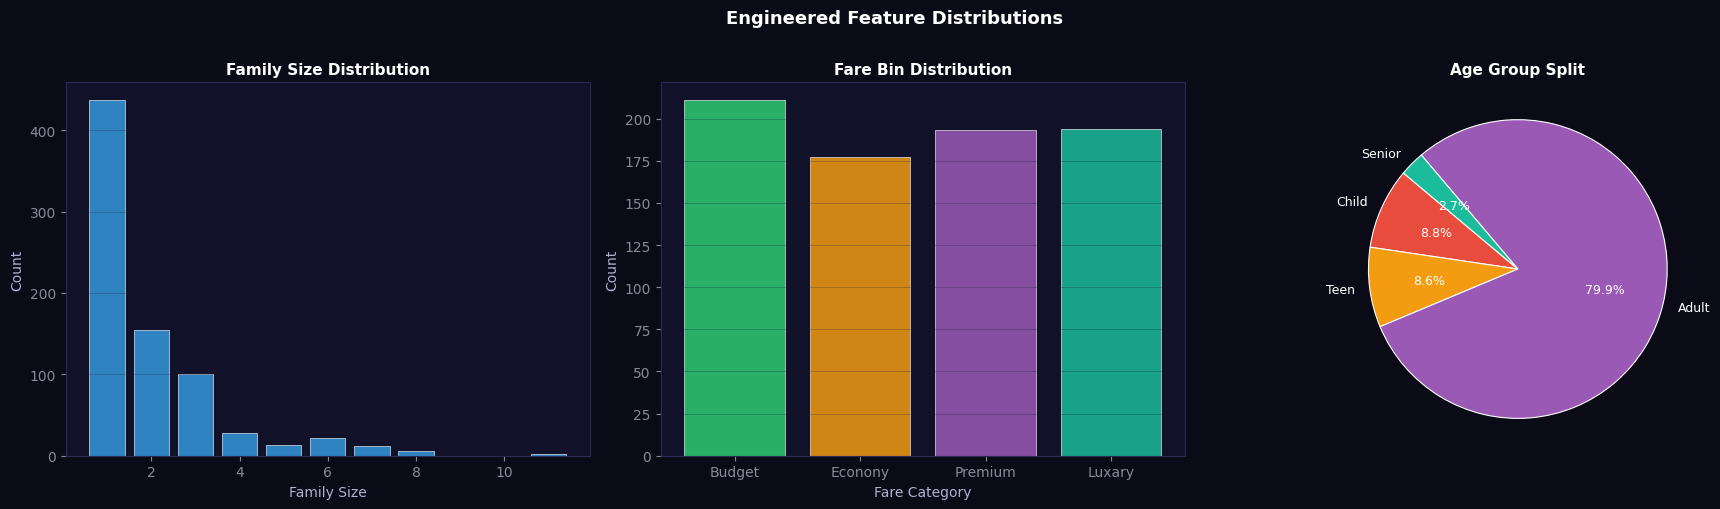

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0b0b18')

# Family size
vals = df['family_size'].value_counts().sort_index()
axes[0].bar(vals.index, vals.values, color=ACCENT[1], edgecolor='white', lw=0.5, alpha=0.85)
axes[0].set_title('Family Size Distribution', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Family Size'); axes[0].set_ylabel('Count')
axes[0].grid(True, axis='y', alpha=0.3)

# Fare bins
fare_counts = df['fare_bin'].value_counts().sort_index()
axes[1].bar(fare_counts.index.astype(str), fare_counts.values,
            color=ACCENT[2:6], edgecolor='white', lw=0.5, alpha=0.85)
axes[1].set_title('Fare Bin Distribution', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Fare Category'); axes[1].set_ylabel('Count')
axes[1].grid(True, axis='y', alpha=0.3)

# Age groups
age_counts = df['age_group'].value_counts().sort_index()
wedge_colors = [ACCENT[0], ACCENT[3], ACCENT[4], ACCENT[5]]
axes[2].pie(age_counts.values, labels=age_counts.index.astype(str),
            colors=wedge_colors[:len(age_counts)], autopct='%1.1f%%',
            startangle=140, textprops={'color':'white','fontsize':9},
            wedgeprops={'edgecolor':'white','linewidth':0.8})
axes[2].set_title('Age Group Split', fontsize=11, fontweight='bold')

plt.suptitle('Engineered Feature Distributions', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feat_eng.png', dpi=150, bbox_inches='tight', facecolor='#0b0b18')
plt.show()

## Part 4: Exploratory Analysis - Grouping & Aggregations

In [9]:
surv_pclass_sex = (
    df.groupby(['pclass','sex'])['survived']
      .agg(['mean','sum','count'])
      .rename(columns={'mean':'Survival Rate','sum':'Survivors','count':'Total'})
      .round(3)
)
print('Survival by Pclass × Sex:')
print(surv_pclass_sex.to_string())

Survival by Pclass × Sex:
               Survival Rate  Survivors  Total
pclass sex                                    
1      female          0.968         90     93
       male            0.368         43    117
2      female          0.917         66     72
       male            0.185         17     92
3      female          0.472         60    127
       male            0.161         44    274


In [10]:
fare_stats = (
    df.groupby('pclass')['fare']
      .agg(['mean','median','std','min','max'])
      .round(2)
)
print('Fare Statistics by Pclass:')
print(fare_stats.to_string())

Fare Statistics by Pclass:
         mean  median    std  min     max
pclass                                   
1       85.68   61.68  78.89  0.0  512.33
2       21.89   18.75  13.50  0.0   73.50
3       13.59    8.05  10.49  0.0   69.55


In [11]:
pivot_surv = pd.pivot_table(
    df, values='survived',
    index='age_group', columns='fare_bin',
    aggfunc='mean'
).round(3)
print('Pivot: Survival Rate by Age Group × Fare Bin:')
print(pivot_surv.to_string())

Pivot: Survival Rate by Age Group × Fare Bin:
fare_bin   Budget  Econony  Premium  Luxary
age_group                                  
Child         NaN    0.857    0.500   0.500
Teen        0.391    0.412    0.333   0.611
Adult       0.223    0.296    0.464   0.641
Senior      0.000    0.500    0.167   0.286


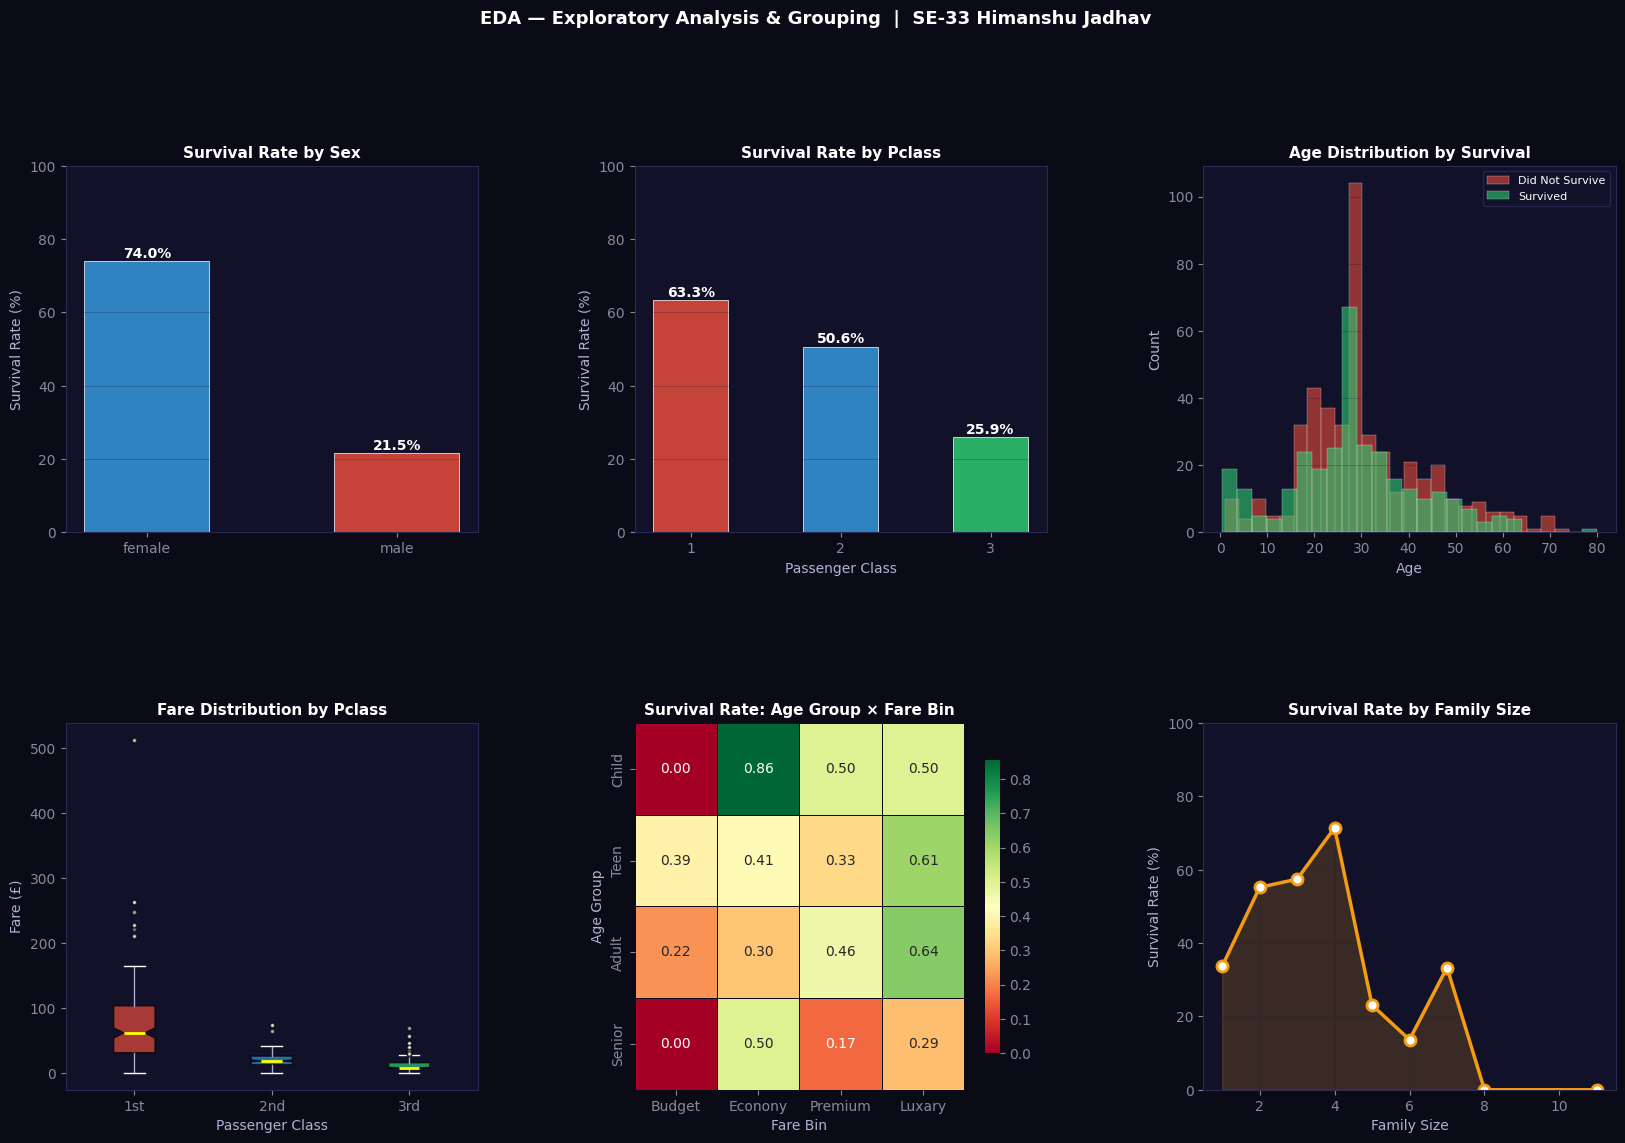

In [12]:
fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor('#0b0b18')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.52, wspace=0.38)

# Survival rate by Sex
ax1 = fig.add_subplot(gs[0, 0])
surv_sex = df.groupby('sex')['survived'].mean().reset_index()
ax1.bar(surv_sex['sex'], surv_sex['survived']*100,
        color=['#3498db','#e74c3c'], edgecolor='white', lw=0.6, alpha=0.85, width=0.5)
for i, r in surv_sex.iterrows():
    ax1.text(i, r['survived']*100 + 1, f"{r['survived']*100:.1f}%",
             ha='center', fontsize=10, fontweight='bold')
ax1.set_title('Survival Rate by Sex', fontsize=11, fontweight='bold')
ax1.set_ylabel('Survival Rate (%)')
ax1.set_ylim(0, 100)
ax1.grid(True, axis='y', alpha=0.3)

# Survival rate by Pclass
ax2 = fig.add_subplot(gs[0, 1])
surv_pclass = df.groupby('pclass')['survived'].mean().reset_index()
bars = ax2.bar(surv_pclass['pclass'].astype(str), surv_pclass['survived']*100,
               color=ACCENT[:3], edgecolor='white', lw=0.6, alpha=0.85, width=0.5)
for bar, v in zip(bars, surv_pclass['survived']*100):
    ax2.text(bar.get_x()+bar.get_width()/2, v+1, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax2.set_title('Survival Rate by Pclass', fontsize=11, fontweight='bold')
ax2.set_xlabel('Passenger Class'); ax2.set_ylabel('Survival Rate (%)')
ax2.set_ylim(0, 100)
ax2.grid(True, axis='y', alpha=0.3)

# Age distribution by survival
ax3 = fig.add_subplot(gs[0, 2])
for surv, col, lbl in zip([0,1], [ACCENT[0], ACCENT[2]], ['Did Not Survive','Survived']):
    ax3.hist(df[df['survived']==surv]['age'], bins=25,
             alpha=0.6, color=col, label=lbl, edgecolor='white', lw=0.3)
ax3.set_title('Age Distribution by Survival', fontsize=11, fontweight='bold')
ax3.set_xlabel('Age'); ax3.set_ylabel('Count')
ax3.legend(fontsize=8, labelcolor='white')
ax3.grid(True, axis='y', alpha=0.3)

# Fare by Pclass — boxplot
ax4 = fig.add_subplot(gs[1, 0])
data_fare = [df[df['pclass']==c]['fare'].values for c in [1,2,3]]
bp = ax4.boxplot(data_fare, labels=['1st','2nd','3rd'], patch_artist=True,
                 notch=True, medianprops=dict(color='yellow', lw=2),
                 whiskerprops=dict(color='#aaaacc'), capprops=dict(color='white'),
                 flierprops=dict(marker='o', markersize=3, alpha=0.4, markerfacecolor='white'))
for patch, col in zip(bp['boxes'], ACCENT[:3]):
    patch.set_facecolor(col); patch.set_alpha(0.7)
ax4.set_title('Fare Distribution by Pclass', fontsize=11, fontweight='bold')
ax4.set_xlabel('Passenger Class'); ax4.set_ylabel('Fare (£)')
ax4.grid(True, axis='y', alpha=0.3)

# Survival pivot heatmap
ax5 = fig.add_subplot(gs[1, 1])
pivot_num = pivot_surv.copy().fillna(0)
sns.heatmap(pivot_num, ax=ax5, annot=True, fmt='.2f',
            cmap='RdYlGn', linewidths=0.5, linecolor='#0b0b18',
            cbar_kws={'shrink':0.8})
ax5.set_title('Survival Rate: Age Group × Fare Bin', fontsize=11, fontweight='bold')
ax5.set_xlabel('Fare Bin'); ax5.set_ylabel('Age Group')

# Family size vs survival
ax6 = fig.add_subplot(gs[1, 2])
fam_surv = df.groupby('family_size')['survived'].mean().reset_index()
ax6.plot(fam_surv['family_size'], fam_surv['survived']*100,
         'o-', color=ACCENT[3], lw=2.5, markersize=8, markerfacecolor='white', markeredgewidth=2)
ax6.fill_between(fam_surv['family_size'], fam_surv['survived']*100, alpha=0.18, color=ACCENT[3])
ax6.set_title('Survival Rate by Family Size', fontsize=11, fontweight='bold')
ax6.set_xlabel('Family Size'); ax6.set_ylabel('Survival Rate (%)')
ax6.set_ylim(0, 100)
ax6.grid(True, alpha=0.3)

fig.suptitle('EDA — Exploratory Analysis & Grouping  |  SE-33 Himanshu Jadhav',
             fontsize=13, fontweight='bold', color='white', y=1.01)
plt.savefig('eda_group.png', dpi=150, bbox_inches='tight', facecolor='#0b0b18')
plt.show()

## Part 5: Correlation Analysis

In [13]:
num_df = df[['survived','pclass','age','sibsp','parch',
             'fare','family_size','is_alone','fare_per_head']]
corr   = num_df.corr()

print('Correlation with Survival (sorted):')
print(corr['survived'].drop('survived').sort_values(key=abs, ascending=False).round(3).to_string())

Correlation with Survival (sorted):
pclass          -0.331
fare             0.247
fare_per_head    0.209
is_alone        -0.177
age             -0.078
parch            0.070
sibsp           -0.038
family_size      0.014


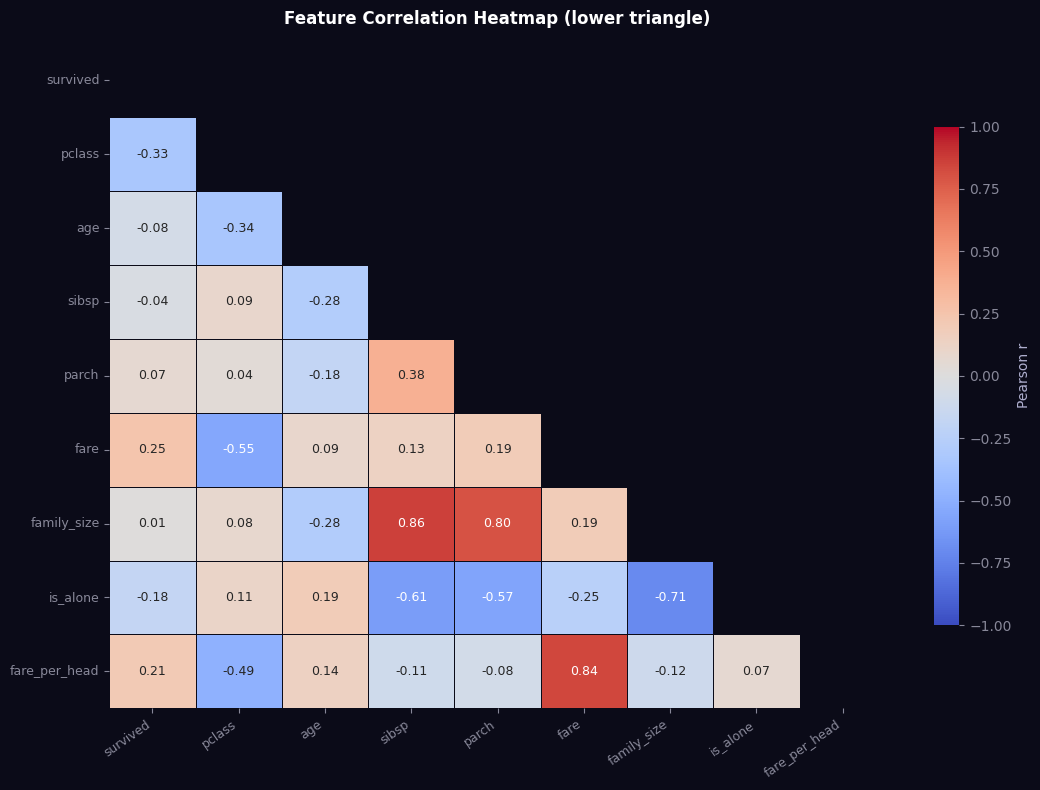

In [14]:
fig, ax = plt.subplots(figsize=(11, 8))
fig.patch.set_facecolor('#0b0b18')
ax.set_facecolor('#0b0b18')

mask = np.triu(np.ones_like(corr, dtype=bool))   # upper triangle mask
sns.heatmap(
    corr, ax=ax, mask=mask,
    annot=True, fmt='.2f', annot_kws={'size':9},
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='#0b0b18',
    cbar_kws={'shrink':0.75, 'label':'Pearson r'}
)

ax.set_title('Feature Correlation Heatmap (lower triangle)',
             fontsize=12, fontweight='bold', pad=14)
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('corr_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0b0b18')
plt.show()

## Part 6: Outlier Detection - IQR Method (reusable function)

In [15]:
def detect_outliers_iqr(df, columns, k=1.5):
    """
    Detect outliers using the IQR method.
    Parameters:
        df      — DataFrame
        columns — list of numeric columns to check
        k       — IQR multiplier (default 1.5)
    Returns:
        summary — DataFrame with Q1, Q3, IQR, bounds, and outlier count
        mask    — boolean Series (True = row has at least one outlier)
    """
    summary_rows = []
    outlier_mask = pd.Series(False, index=df.index)

    for col in columns:
        Q1  = df[col].quantile(0.25)
        Q3  = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lo  = Q1 - k * IQR
        hi  = Q3 + k * IQR

        is_out = (df[col] < lo) | (df[col] > hi)
        outlier_mask |= is_out

        summary_rows.append({
            'Column'       : col,
            'Q1'           : round(Q1, 2),
            'Q3'           : round(Q3, 2),
            'IQR'          : round(IQR, 2),
            'Lower Bound'  : round(lo, 2),
            'Upper Bound'  : round(hi, 2),
            'Outliers'     : int(is_out.sum()),
            'Outlier %'    : round(is_out.mean() * 100, 2)
        })

    return pd.DataFrame(summary_rows).set_index('Column'), outlier_mask


target_cols = ['age', 'fare', 'fare_per_head', 'family_size']
outlier_summary, out_mask = detect_outliers_iqr(df, target_cols)

print('IQR Outlier Detection Summary:')
print(outlier_summary.to_string())
print(f'\nRows with ≥1 outlier: {out_mask.sum()} ({out_mask.mean()*100:.1f}%)')

IQR Outlier Detection Summary:
                  Q1    Q3    IQR  Lower Bound  Upper Bound  Outliers  Outlier %
Column                                                                          
age            21.00  36.0  15.00        -1.50        58.50        27       3.48
fare            8.05  34.2  26.15       -31.17        73.42       102      13.16
fare_per_head   7.25  26.0  18.75       -20.88        54.12        55       7.10
family_size     1.00   2.0   1.00        -0.50         3.50        83      10.71

Rows with ≥1 outlier: 200 (25.8%)


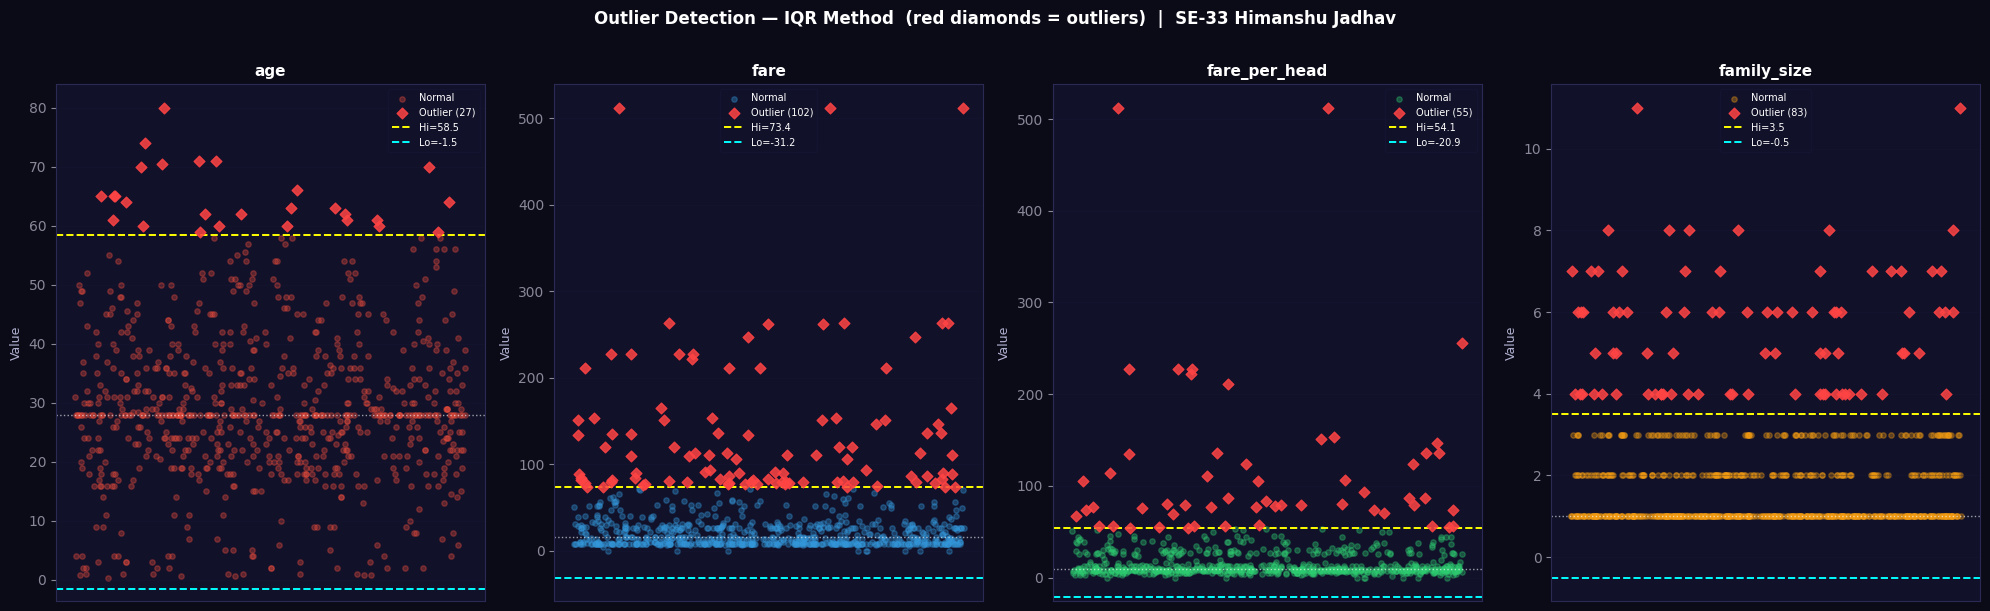

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.patch.set_facecolor('#0b0b18')

for ax, col, color in zip(axes, target_cols, ACCENT[:4]):
    # Compute bounds for shading
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo  = Q1 - 1.5 * IQR
    hi  = Q3 + 1.5 * IQR

    # Strip plot (all points)
    np.random.seed(0)
    jitter = np.random.uniform(-0.15, 0.15, len(df))
    is_out = (df[col] < lo) | (df[col] > hi)

    ax.scatter(jitter[~is_out], df.loc[~is_out, col],
               alpha=0.35, s=15, color=color, label='Normal')
    ax.scatter(jitter[is_out],  df.loc[is_out,  col],
               alpha=0.85, s=30, color='#ff4444', marker='D', label=f'Outlier ({is_out.sum()})', zorder=5)

    # IQR fence lines
    ax.axhline(hi, color='yellow', ls='--', lw=1.4, label=f'Hi={hi:.1f}')
    ax.axhline(lo, color='cyan',   ls='--', lw=1.4, label=f'Lo={lo:.1f}')
    ax.axhline(df[col].median(), color='white', ls=':', lw=1, alpha=0.6)

    ax.set_title(f'{col}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Value', fontsize=9)
    ax.set_xticks([])
    ax.legend(fontsize=7, framealpha=0.15, labelcolor='white')
    ax.grid(True, axis='y', alpha=0.3)

fig.suptitle('Outlier Detection — IQR Method  (red diamonds = outliers)  |  SE-33 Himanshu Jadhav',
             fontsize=12, fontweight='bold', color='white', y=1.01)
plt.tight_layout()
plt.savefig('outliers.png', dpi=150, bbox_inches='tight', facecolor='#0b0b18')
plt.show()

In [17]:
df_clean = df[~out_mask].reset_index(drop=True)
print(f'Shape before outlier removal : {df.shape}')
print(f'Shape after  outlier removal : {df_clean.shape}')
print(f'Rows removed                 : {len(df) - len(df_clean)}')

Shape before outlier removal : (775, 19)
Shape after  outlier removal : (575, 19)
Rows removed                 : 200
